In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [6]:
df = pd.read_csv("../Data/nav_history.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../Data/nav_history.csv'

In [7]:
import os
print("Current folder:", os.getcwd())
print("Data exists:", os.path.exists("../Data/Processed/nav_history.csv"))

Current folder: d:\MutualFundAnalytics\Notebooks
Data exists: True


In [1]:
import pandas as pd
df=pd.read_csv("../Data/Processed/nav_history.csv")
df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [2]:
df["date"] = pd.to_datetime(df["date"])

In [4]:
df = df.sort_values(["amfi_code","date"])

In [5]:
df["daily_return"] = df.groupby("amfi_code")["nav"].pct_change()

In [6]:
df.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [7]:
result=[]

for code,data in df.groupby("amfi_code"):

    start=data.iloc[0]["nav"]
    end=data.iloc[-1]["nav"]

    years=(data["date"].max()-data["date"].min()).days/365

    cagr=((end/start)**(1/years))-1

    result.append([code,cagr])

cagr_df=pd.DataFrame(result,columns=["amfi_code","CAGR"])

In [10]:
import numpy as np

In [11]:
rf=0.065

sharpe=[]

for code,data in df.groupby("amfi_code"):

    avg=data["daily_return"].mean()*252

    std=data["daily_return"].std()*np.sqrt(252)

    ratio=(avg-rf)/std

    sharpe.append([code,ratio])

sharpe_df=pd.DataFrame(sharpe,columns=["amfi_code","Sharpe"])

In [12]:
sortino=[]

for code,data in df.groupby("amfi_code"):

    downside=data[data["daily_return"]<0]["daily_return"]

    downside_std=downside.std()*np.sqrt(252)

    avg=data["daily_return"].mean()*252

    ratio=(avg-rf)/downside_std

    sortino.append([code,ratio])

sortino_df=pd.DataFrame(sortino,
columns=["amfi_code","Sortino"])

In [14]:
benchmark=pd.read_csv("../Data/Raw/10_benchmark_indices.csv")

In [16]:
df["date"] = pd.to_datetime(df["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [18]:
merged = df.merge(
benchmark,
on="date",
how="left"
)

In [20]:
from scipy.stats import linregress

In [22]:
print(benchmark.columns)

Index(['date', 'index_name', 'close_value'], dtype='str')


In [23]:
print(merged.columns)

Index(['amfi_code', 'date', 'nav', 'daily_return', 'index_name',
       'close_value'],
      dtype='str')


In [25]:
benchmark = benchmark.sort_values("date")

benchmark["benchmark_return"] = (
    benchmark["close_value"].pct_change()
)

In [26]:
merged = df.merge(
    benchmark,
    on="date",
    how="left"
)

In [27]:
print(merged.columns)

Index(['amfi_code', 'date', 'nav', 'daily_return', 'index_name', 'close_value',
       'benchmark_return'],
      dtype='str')


In [28]:
alpha_beta=[]

for code,data in merged.groupby("amfi_code"):

    slope,intercept,r,p,std=linregress(
        data["benchmark_return"],
        data["daily_return"]
    )

    alpha=intercept*252
    beta=slope

    alpha_beta.append([code,alpha,beta])

alpha_beta_df=pd.DataFrame(
alpha_beta,
columns=["amfi_code","Alpha","Beta"]
)

In [29]:
alpha_beta_df.to_csv(
"alpha_beta.csv",
index=False
)

In [30]:
draw=[]

for code,data in df.groupby("amfi_code"):

    running_max=data["nav"].cummax()

    drawdown=(data["nav"]/running_max)-1

    draw.append([code,drawdown.min()])

draw_df=pd.DataFrame(draw,
columns=["amfi_code","Max_Drawdown"])

In [31]:
score=cagr_df.merge(sharpe_df)
score=score.merge(sortino_df)
score=score.merge(draw_df)

In [32]:
score["Score"]=(
score["CAGR"]*30+
score["Sharpe"]*25+
score["Sortino"]*20
)

In [33]:
score.to_csv(
"fund_scorecard.csv",
index=False
)

In [34]:
top5=score.sort_values(
"Score",
ascending=False
).head()

In [36]:
import matplotlib.pyplot as plt

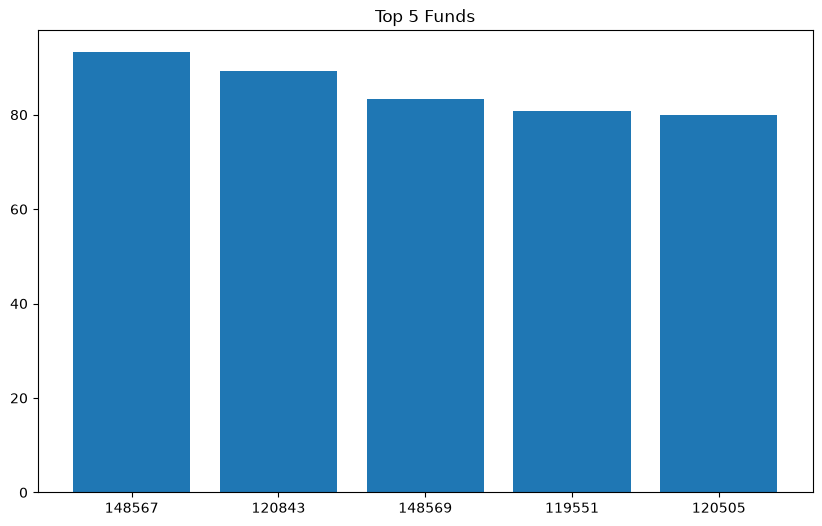

In [37]:
plt.figure(figsize=(10,6))

plt.bar(
top5["amfi_code"].astype(str),
top5["Score"]
)

plt.title("Top 5 Funds")

plt.savefig(
"benchmark_comparison.png"
)

plt.show()